<a href="https://www.kaggle.com/code/aamir28/imdb-top-movies-eda?scriptVersionId=329629418" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="background:#1a1410;border-radius:14px;font-family:'Georgia',serif;overflow:hidden;border:2px solid #d4af37;">

  <div style="background:linear-gradient(180deg,#2a1f15 0%,#1a1410 100%);padding:34px 44px;text-align:center;border-bottom:1px solid #d4af37;">
    <div style="font-size:0.65rem;letter-spacing:5px;color:#d4af37;margin-bottom:10px;">★ ★ ★ NOW SCREENING ★ ★ ★</div>
    <h1 style="margin:0;font-size:2.2rem;font-weight:700;color:#f5e6c8;letter-spacing:1px;">IMDb TOP MOVIES</h1>
    <div style="font-size:0.95rem;color:#c9a876;letter-spacing:3px;margin-top:6px;">1980 — 2026</div>
    <div style="width:120px;height:2px;background:#d4af37;margin:16px auto;"></div>
    <p style="color:#b5a18a;font-size:0.85rem;max-width:560px;margin:0 auto;line-height:1.8;font-style:italic;">
      Forty-six years of cinema. 16,252 titles. One question worth asking: are movies actually getting worse —
      or are we just rating them differently?
    </p>
  </div>

  <!-- Cast/credits style stat block -->
  <div style="padding:24px 44px;display:grid;grid-template-columns:repeat(4,1fr);gap:0;background:#15100c;">
    <div style="text-align:center;padding:10px;border-right:1px solid #3a2f20;">
      <div style="font-size:1.6rem;color:#d4af37;font-weight:700;">16,252</div>
      <div style="font-size:0.62rem;color:#8a7a63;letter-spacing:2px;margin-top:4px;">TITLES</div>
    </div>
    <div style="text-align:center;padding:10px;border-right:1px solid #3a2f20;">
      <div style="font-size:1.6rem;color:#d4af37;font-weight:700;">6.40</div>
      <div style="font-size:0.62rem;color:#8a7a63;letter-spacing:2px;margin-top:4px;">MEAN RATING</div>
    </div>
    <div style="text-align:center;padding:10px;border-right:1px solid #3a2f20;">
      <div style="font-size:1.6rem;color:#d4af37;font-weight:700;">9.3</div>
      <div style="font-size:0.62rem;color:#8a7a63;letter-spacing:2px;margin-top:4px;">TOP SCORE</div>
    </div>
    <div style="text-align:center;padding:10px;">
      <div style="font-size:1.6rem;color:#d4af37;font-weight:700;">3.18M</div>
      <div style="font-size:0.62rem;color:#8a7a63;letter-spacing:2px;margin-top:4px;">MOST VOTES</div>
    </div>
  </div>

  <!-- Marquee billing -->
  <div style="padding:22px 44px;background:#1a1410;border-top:1px solid #3a2f20;">
    <div style="font-size:0.65rem;letter-spacing:3px;color:#d4af37;margin-bottom:10px;text-align:center;">★ FEATURED FINDINGS ★</div>
    <div style="display:grid;grid-template-columns:1fr 1fr;gap:10px;">
      <div style="background:#15100c;border:1px solid #3a2f20;border-radius:4px;padding:10px 14px;text-align:center;">
        <span style="color:#f5e6c8;font-size:0.82rem;">Avg rating fell <strong style='color:#d4af37'>6.55 → 6.23</strong> from the 1980s to 2020s</span>
      </div>
      <div style="background:#15100c;border:1px solid #3a2f20;border-radius:4px;padding:10px 14px;text-align:center;">
        <span style="color:#f5e6c8;font-size:0.82rem;">Documentaries (7.31) outscore every genre; Horror (5.56) trails</span>
      </div>
      <div style="background:#15100c;border:1px solid #3a2f20;border-radius:4px;padding:10px 14px;text-align:center;">
        <span style="color:#f5e6c8;font-size:0.82rem;">Longer runtime correlates with higher ratings (r=0.31)</span>
      </div>
      <div style="background:#15100c;border:1px solid #3a2f20;border-radius:4px;padding:10px 14px;text-align:center;">
        <span style="color:#f5e6c8;font-size:0.82rem;">Blockbusters (500K+ votes) average <strong style='color:#d4af37'>7.74</strong> vs 6.20 for niche films</span>
      </div>
    </div>
  </div>

  <div style="background:#0f0b08;padding:8px 44px;text-align:right;">
    <span style="font-size:0.68rem;color:#5a4d3c;">Directed by Muhammad Aamir · A Kaggle Notebook Production</span>
  </div>
</div>


## 🎬 Table of Contents
1. [Setup & Data Loading](#1)
2. [EDA & Data Quality](#2)
3. [Feature Engineering](#3)
4. [Are Movies Getting Worse? — The Decade Trend](#4)
5. [Genre Rankings — Who Makes the Best Films?](#5)
6. [Runtime vs Quality](#6)
7. [The Popularity-Quality Connection](#7)
8. [All-Time Greats & Most-Watched](#8)
9. [Genre Trends Over Time](#9)
10. [Correlation Heatmap](#10)
11. [ML — Predicting High Ratings](#11)
12. [Key Takeaways](#12)


## 1. Setup & Data Loading <a id='1'></a>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
from collections import Counter
import warnings; warnings.filterwarnings('ignore')

# Cinema marquee dark theme — deep brown/black with gold accent
BG, PANEL, GRID = '#1a1410','#15100c','#3a2f20'
plt.rcParams.update({
    'figure.facecolor':BG,'axes.facecolor':PANEL,'axes.edgecolor':GRID,
    'axes.labelcolor':'#b5a18a','axes.titlecolor':'#f5e6c8','axes.titlesize':13,
    'xtick.color':'#8a7a63','ytick.color':'#8a7a63','text.color':'#b5a18a',
    'grid.color':'#241c14','grid.linewidth':0.6,
    'legend.facecolor':BG,'legend.edgecolor':GRID,'font.family':'DejaVu Sans',
})

GOLD   = '#d4af37'
RED    = '#c0392b'
CREAM  = '#f5e6c8'
TEAL   = '#3a8a8a'
VIOLET = '#9370a8'
GREEN  = '#5a8a5a'
ORANGE = '#cc7722'
CMAP_GOLD = LinearSegmentedColormap.from_list('gd', [BG, GOLD, CREAM])
CMAP_FILM = LinearSegmentedColormap.from_list('fm', [RED, BG, GOLD])
print('✅  Cinema marquee theme loaded. 16,252 titles ready for review.')


✅  Cinema marquee theme loaded. 16,252 titles ready for review.


In [2]:
df = pd.read_csv('/kaggle/input/datasets/elvisbui/imdb-top-movies-1980-2026/imdb_top_movies_1980_2026.csv')
print(f'Shape: {df.shape}')
print(f'Year range: {df.year.min()}–{df.year.max()}')
df.head(8)


Shape: (16252, 9)
Year range: 1980–2026


,imdb_id,title,original_title,year,runtime_minutes,genres,average_rating,num_votes,imdb_url
0,tt0111161,The Shawshank Redemption,The Shawshank Redemption,1994,142.0,Drama,9.3,3182733,https://www.imdb.com/title/tt0111161
1,tt0468569,The Dark Knight,The Dark Knight,2008,152.0,"Action,Crime,Drama",9.1,3161984,https://www.imdb.com/title/tt0468569
2,tt1375666,Inception,Inception,2010,148.0,"Action,Adventure,Sci-Fi",8.8,2811692,https://www.imdb.com/title/tt1375666
3,tt0137523,Fight Club,Fight Club,1999,139.0,"Crime,Drama,Thriller",8.8,2601984,https://www.imdb.com/title/tt0137523
4,tt0816692,Interstellar,Interstellar,2014,169.0,"Adventure,Drama,Sci-Fi",8.7,2521607,https://www.imdb.com/title/tt0816692
5,tt0109830,Forrest Gump,Forrest Gump,1994,142.0,"Drama,Romance",8.8,2492584,https://www.imdb.com/title/tt0109830
6,tt0110912,Pulp Fiction,Pulp Fiction,1994,154.0,"Crime,Drama",8.8,2431723,https://www.imdb.com/title/tt0110912
7,tt0133093,The Matrix,The Matrix,1999,136.0,"Action,Sci-Fi",8.7,2243917,https://www.imdb.com/title/tt0133093


## 2. EDA & Data Quality <a id='2'></a>


In [3]:
print('=== Data Types & Nulls ===')
df.info()
print('\n=== Descriptive Statistics ===')
df[['year','runtime_minutes','average_rating','num_votes']].describe().round(2)


=== Data Types & Nulls ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16252 entries, 0 to 16251
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   imdb_id          16252 non-null  object 
 1   title            16252 non-null  object 
 2   original_title   16252 non-null  object 
 3   year             16252 non-null  int64  
 4   runtime_minutes  16251 non-null  float64
 5   genres           16246 non-null  object 
 6   average_rating   16252 non-null  float64
 7   num_votes        16252 non-null  int64  
 8   imdb_url         16252 non-null  object 
dtypes: float64(2), int64(2), object(5)
memory usage: 1.1+ MB

=== Descriptive Statistics ===


,year,runtime_minutes,average_rating,num_votes
count,16252.00,16251.00,16252.00,16252.00
mean,2008.79,109.15,6.40,66331.72
std,11.58,22.11,1.05,155736.56
min,1980.00,43.00,1.00,5000.00
25%,2001.00,94.00,5.80,8397.50
50%,2011.00,104.00,6.50,17266.00
75%,2018.00,119.00,7.10,53867.25
max,2026.00,566.00,9.30,3182733.00


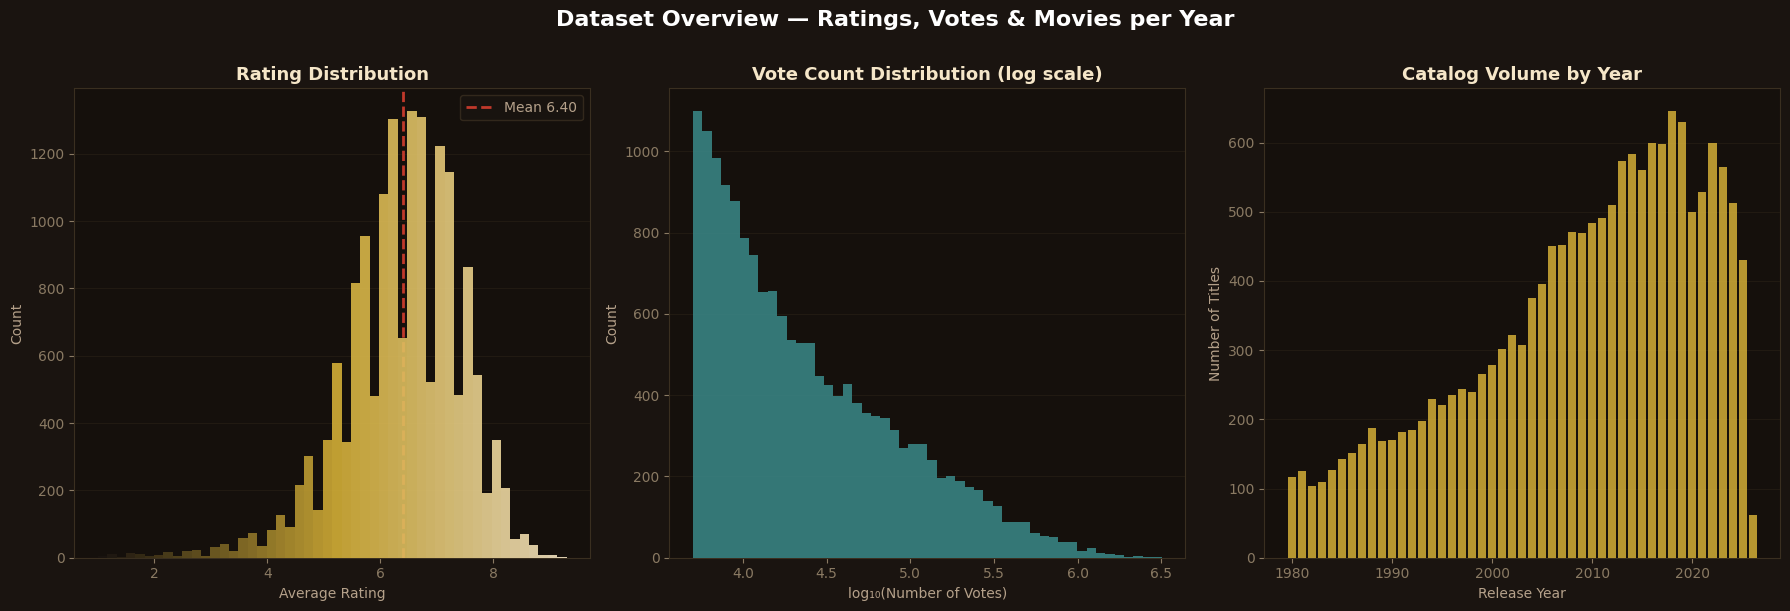

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor(BG)
fig.suptitle('Dataset Overview — Ratings, Votes & Movies per Year', fontsize=16, fontweight='bold', color='white', y=1.01)

# 1. Rating histogram
ax = axes[0]
n, bins, patches = ax.hist(df['average_rating'], bins=50, edgecolor='none', alpha=0.9, zorder=3)
for patch, left in zip(patches, bins[:-1]):
    t = (left - bins[0]) / (bins[-1] - bins[0] + 1e-9)
    patch.set_facecolor(CMAP_GOLD(t))
ax.axvline(df['average_rating'].mean(), color=RED, lw=2, ls='--', label=f'Mean {df["average_rating"].mean():.2f}')
ax.set_xlabel('Average Rating'); ax.set_ylabel('Count')
ax.set_title('Rating Distribution', fontweight='bold')
ax.legend(fontsize=10); ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 2. Votes histogram (log)
ax = axes[1]
ax.hist(np.log10(df['num_votes'].clip(1)), bins=50, color=TEAL, alpha=0.85, edgecolor='none', zorder=3)
ax.set_xlabel('log₁₀(Number of Votes)'); ax.set_ylabel('Count')
ax.set_title('Vote Count Distribution (log scale)', fontweight='bold')
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 3. Movies per year
ax = axes[2]
yr_counts = df['year'].value_counts().sort_index()
ax.bar(yr_counts.index, yr_counts.values, color=GOLD, width=0.8, zorder=3, alpha=0.85)
ax.set_xlabel('Release Year'); ax.set_ylabel('Number of Titles')
ax.set_title('Catalog Volume by Year', fontweight='bold')
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('01_overview.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 3. Feature Engineering <a id='3'></a>


In [5]:
df['decade'] = (df['year'] // 10 * 10).astype(int)
df['primary_genre'] = df['genres'].str.split(',').str[0].str.strip()
df['genre_count'] = df['genres'].str.split(',')
df['log_votes'] = np.log10(df['num_votes'].clip(1))

# Vote tier (popularity bucket)
df['vote_tier'] = pd.cut(df['num_votes'],
    bins=[0,1000,10000,100000,500000,5_000_000],
    labels=['<1K','1K-10K','10K-100K','100K-500K','500K+'])

# Runtime band
df['runtime_band'] = pd.cut(df['runtime_minutes'],
    bins=[0,80,100,120,150,600],
    labels=['<80min','80-99min','100-119min','120-149min','150min+'])

# High-rated flag (top quartile, with vote floor to exclude obscure outliers)
df['is_acclaimed'] = ((df['average_rating'] >= 7.5) & (df['num_votes'] >= 10000)).astype(int)

print('Engineered: decade, primary_genre, genre_count, log_votes, vote_tier, runtime_band, is_acclaimed')
print(f'\nAcclaimed films (rating≥7.5, votes≥10K): {df["is_acclaimed"].sum():,} ({df["is_acclaimed"].mean()*100:.1f}%)')


Engineered: decade, primary_genre, genre_count, log_votes, vote_tier, runtime_band, is_acclaimed

Acclaimed films (rating≥7.5, votes≥10K): 1,751 (10.8%)


## 4. Are Movies Getting Worse? — The Decade Trend <a id='4'></a>


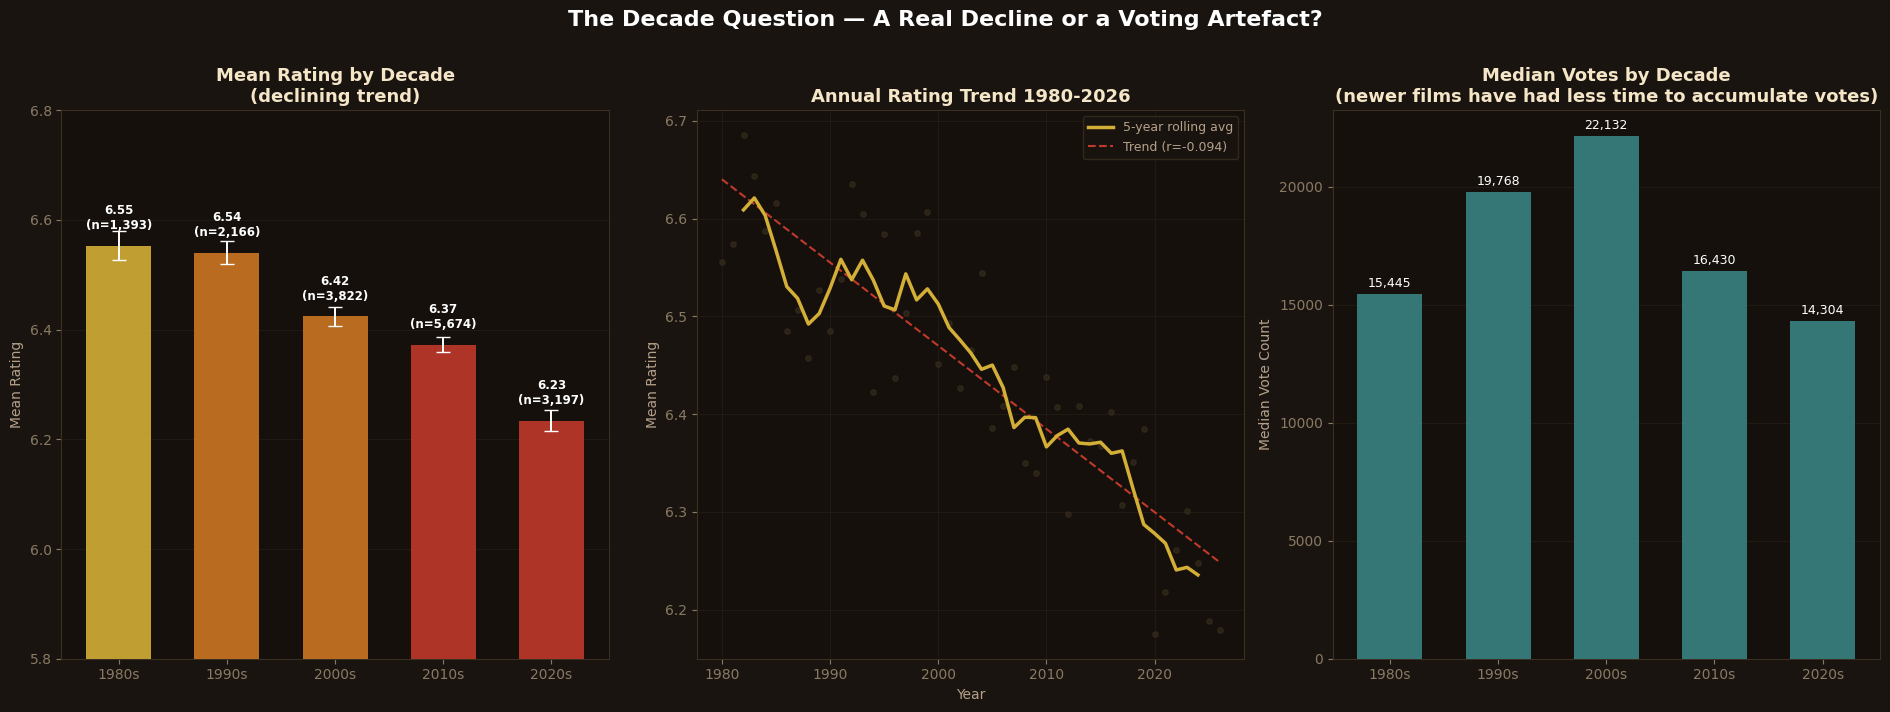

Mean rating by decade:
            mean       sem  count
decade                           
1980    6.552692  0.026221   1393
1990    6.539658  0.020890   2166
2000    6.424254  0.017269   3822
2010    6.372541  0.013842   5674
2020    6.234157  0.019478   3197


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(19, 7))
fig.patch.set_facecolor(BG)
fig.suptitle('The Decade Question — A Real Decline or a Voting Artefact?',
             fontsize=16, fontweight='bold', color='white', y=1.01)

# 1. Mean rating by decade with error bars
ax = axes[0]
decade_stats = df.groupby('decade')['average_rating'].agg(['mean','sem','count'])
bars = ax.bar(decade_stats.index.astype(str)+'s', decade_stats['mean'], yerr=decade_stats['sem'],
              color=[GOLD if i==0 else ORANGE if i<3 else RED for i in range(5)],
              width=0.6, zorder=3, edgecolor='none', alpha=0.9, capsize=5,
              error_kw=dict(ecolor='white', elinewidth=1.4))
ax.set_ylabel('Mean Rating'); ax.set_title('Mean Rating by Decade\n(declining trend)', fontweight='bold')
ax.set_ylim(5.8, 6.8)
for bar, v, n in zip(bars, decade_stats['mean'], decade_stats['count']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.03, f'{v:.2f}\n(n={n:,})', ha='center', fontsize=8.5, fontweight='bold', color='white')
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 2. Year-by-year rolling average
ax = axes[1]
yr_mean = df.groupby('year')['average_rating'].mean()
rolling = yr_mean.rolling(5, center=True).mean()
ax.scatter(yr_mean.index, yr_mean.values, color=GRID, s=15, alpha=0.6, zorder=3)
ax.plot(rolling.index, rolling.values, color=GOLD, lw=2.5, zorder=5, label='5-year rolling avg')
m, b, r, p, _ = stats.linregress(df['year'], df['average_rating'])
xr = np.linspace(1980, 2026, 50)
ax.plot(xr, m*xr+b, color=RED, lw=1.5, ls='--', zorder=4, label=f'Trend (r={r:.3f})')
ax.set_xlabel('Year'); ax.set_ylabel('Mean Rating')
ax.set_title('Annual Rating Trend 1980-2026', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, zorder=0); ax.set_axisbelow(True)

# 3. Vote count by decade — is the decline a recency/vote-maturity effect?
ax = axes[2]
vote_by_decade = df.groupby('decade')['num_votes'].median()
bars2 = ax.bar(vote_by_decade.index.astype(str)+'s', vote_by_decade.values,
               color=TEAL, width=0.6, zorder=3, alpha=0.85)
ax.set_ylabel('Median Vote Count')
ax.set_title('Median Votes by Decade\n(newer films have had less time to accumulate votes)', fontweight='bold')
for bar, v in zip(bars2, vote_by_decade.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+300, f'{v:,.0f}', ha='center', fontsize=9, color='white')
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('02_decade_trend.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Mean rating by decade:')
print(decade_stats)


## 5. Genre Rankings — Who Makes the Best Films? <a id='5'></a>


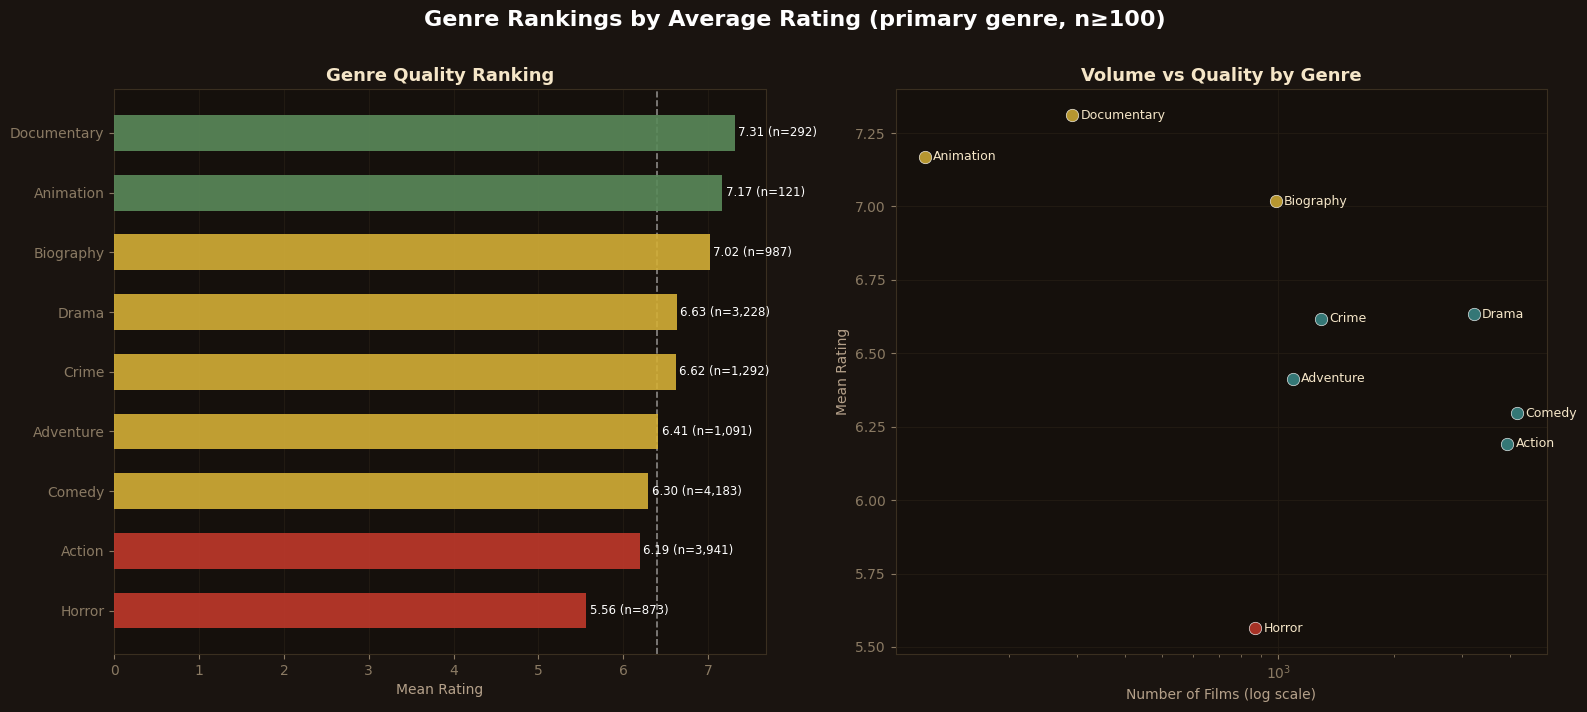

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor(BG)
fig.suptitle('Genre Rankings by Average Rating (primary genre, n≥100)', fontsize=16, fontweight='bold', color='white', y=1.01)

genre_stats = df.groupby('primary_genre')['average_rating'].agg(['mean','count']).query('count>=100').sort_values('mean')

# 1. Ranked bar
ax = axes[0]
colors_g = [GREEN if i>=len(genre_stats)-2 else (RED if i<2 else GOLD) for i in range(len(genre_stats))]
bars = ax.barh(range(len(genre_stats)), genre_stats['mean'], color=colors_g, height=0.6, zorder=3, edgecolor='none', alpha=0.9)
ax.set_yticks(range(len(genre_stats))); ax.set_yticklabels(genre_stats.index, fontsize=10)
ax.set_xlabel('Mean Rating')
ax.set_title('Genre Quality Ranking', fontweight='bold')
ax.axvline(df['average_rating'].mean(), color='white', lw=1.2, ls='--', alpha=0.5)
for bar, v, n in zip(bars, genre_stats['mean'], genre_stats['count']):
    ax.text(bar.get_width()+0.04, bar.get_y()+bar.get_height()/2, f'{v:.2f} (n={n:,})', va='center', fontsize=8.5, color='white')
ax.grid(axis='x', zorder=0); ax.set_axisbelow(True)

# 2. Genre volume vs quality scatter
ax = axes[1]
for i, (g, row) in enumerate(genre_stats.iterrows()):
    color = GOLD if row['mean']>=7 else (RED if row['mean']<6 else TEAL)
    ax.scatter(row['count'], row['mean'], s=80, color=color, alpha=0.85, edgecolors='white', linewidths=0.5, zorder=4)
    ax.text(row['count']*1.05, row['mean'], g, fontsize=9, color=CREAM, va='center')
ax.set_xscale('log')
ax.set_xlabel('Number of Films (log scale)'); ax.set_ylabel('Mean Rating')
ax.set_title('Volume vs Quality by Genre', fontweight='bold')
ax.grid(True, zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('03_genre_rankings.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 6. Runtime vs Quality <a id='6'></a>


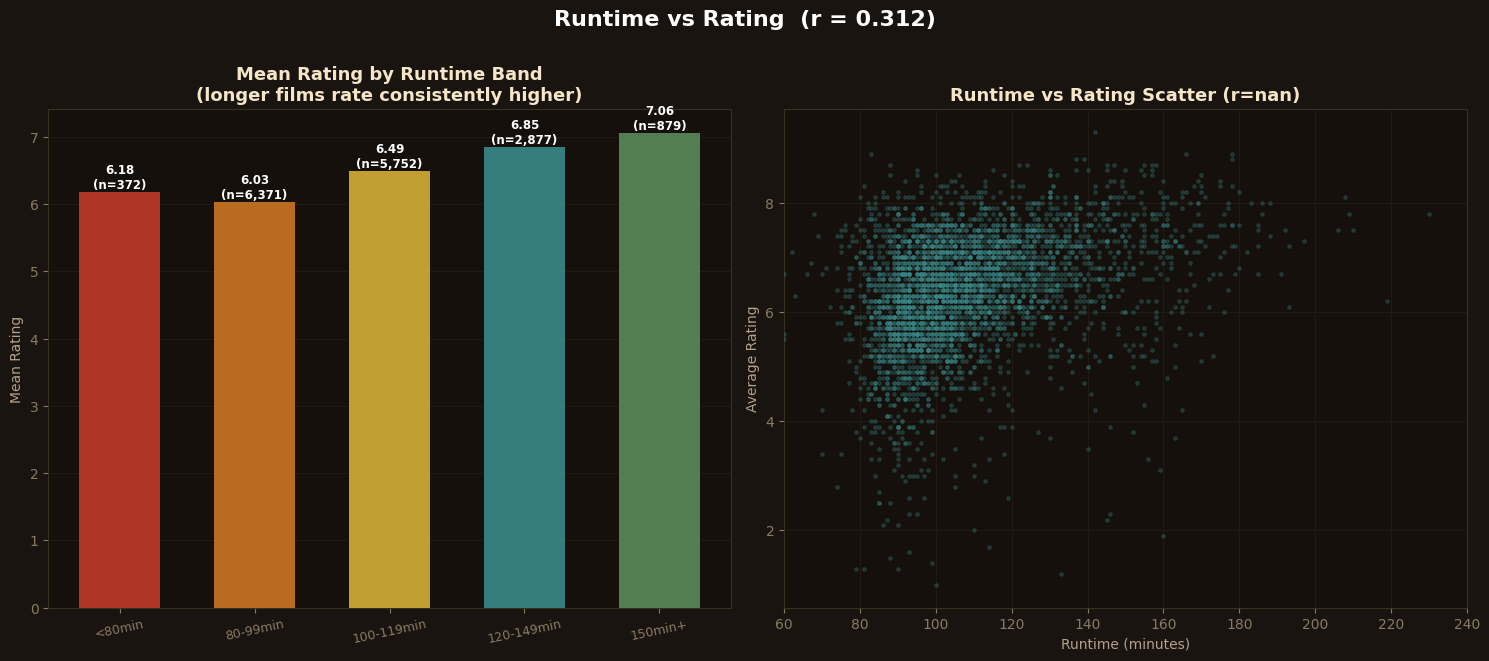

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
fig.patch.set_facecolor(BG)
fig.suptitle(f'Runtime vs Rating  (r = {df[["runtime_minutes","average_rating"]].corr().iloc[0,1]:.3f})',
             fontsize=16, fontweight='bold', color='white', y=1.01)

# 1. Runtime band vs mean rating
ax = axes[0]
rt_order = ['<80min','80-99min','100-119min','120-149min','150min+']
rt_means = df.groupby('runtime_band', observed=True)['average_rating'].mean().reindex(rt_order)
rt_ns    = df.groupby('runtime_band', observed=True)['average_rating'].count().reindex(rt_order)
bars = ax.bar(range(5), rt_means.values, color=[RED,ORANGE,GOLD,TEAL,GREEN], width=0.6, zorder=3, alpha=0.9)
ax.set_xticks(range(5)); ax.set_xticklabels(rt_order, fontsize=9, rotation=12)
ax.set_ylabel('Mean Rating')
ax.set_title('Mean Rating by Runtime Band\n(longer films rate consistently higher)', fontweight='bold')
for bar, v, n in zip(bars, rt_means.values, rt_ns.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05, f'{v:.2f}\n(n={n:,})', ha='center', fontsize=8.5, fontweight='bold', color='white')
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 2. Scatter with regression
ax = axes[1]
sample = df.sample(min(4000, len(df)), random_state=42)
ax.scatter(sample['runtime_minutes'], sample['average_rating'], color=TEAL, s=6, alpha=0.25, zorder=3)
m, b, r, p, _ = stats.linregress(df['runtime_minutes'], df['average_rating'])
xr = np.linspace(60, 240, 80)
ax.plot(xr, m*xr+b, color=GOLD, lw=2.2, zorder=5)
ax.set_xlim(60, 240)
ax.set_xlabel('Runtime (minutes)'); ax.set_ylabel('Average Rating')
ax.set_title(f'Runtime vs Rating Scatter (r={r:.3f})', fontweight='bold')
ax.grid(True, zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('04_runtime.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 7. The Popularity-Quality Connection <a id='7'></a>


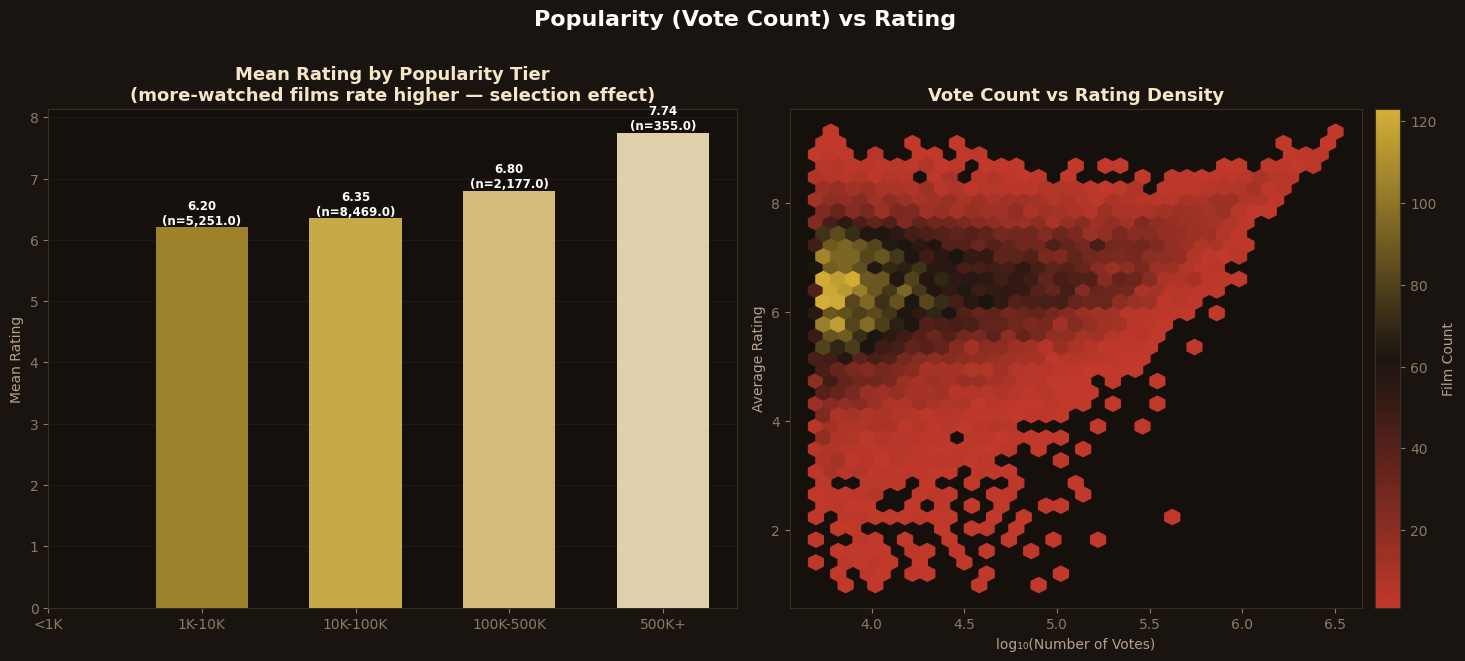

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
fig.patch.set_facecolor(BG)
fig.suptitle('Popularity (Vote Count) vs Rating', fontsize=16, fontweight='bold', color='white', y=1.01)

# 1. Vote tier vs mean rating
ax = axes[0]
vt_order = ['<1K','1K-10K','10K-100K','100K-500K','500K+']
vt_means = df.groupby('vote_tier', observed=True)['average_rating'].mean().reindex(vt_order)
vt_ns    = df.groupby('vote_tier', observed=True)['average_rating'].count().reindex(vt_order)
bars = ax.bar(range(5), vt_means.values, color=CMAP_GOLD(np.linspace(0.2,0.95,5)), width=0.6, zorder=3, alpha=0.92)
ax.set_xticks(range(5)); ax.set_xticklabels(vt_order, fontsize=10)
ax.set_ylabel('Mean Rating')
ax.set_title('Mean Rating by Popularity Tier\n(more-watched films rate higher — selection effect)', fontweight='bold')
for bar, v, n in zip(bars, vt_means.values, vt_ns.values):
    if not np.isnan(v):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05, f'{v:.2f}\n(n={n:,})', ha='center', fontsize=8.5, fontweight='bold', color='white')
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 2. log(votes) vs rating density scatter
ax = axes[1]
sc = ax.hexbin(df['log_votes'], df['average_rating'], gridsize=35, cmap=CMAP_FILM, mincnt=1)
plt.colorbar(sc, ax=ax, label='Film Count', pad=0.02)
ax.set_xlabel('log₁₀(Number of Votes)'); ax.set_ylabel('Average Rating')
ax.set_title('Vote Count vs Rating Density', fontweight='bold')

plt.tight_layout()
plt.savefig('05_popularity.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 8. All-Time Greats & Most-Watched <a id='8'></a>


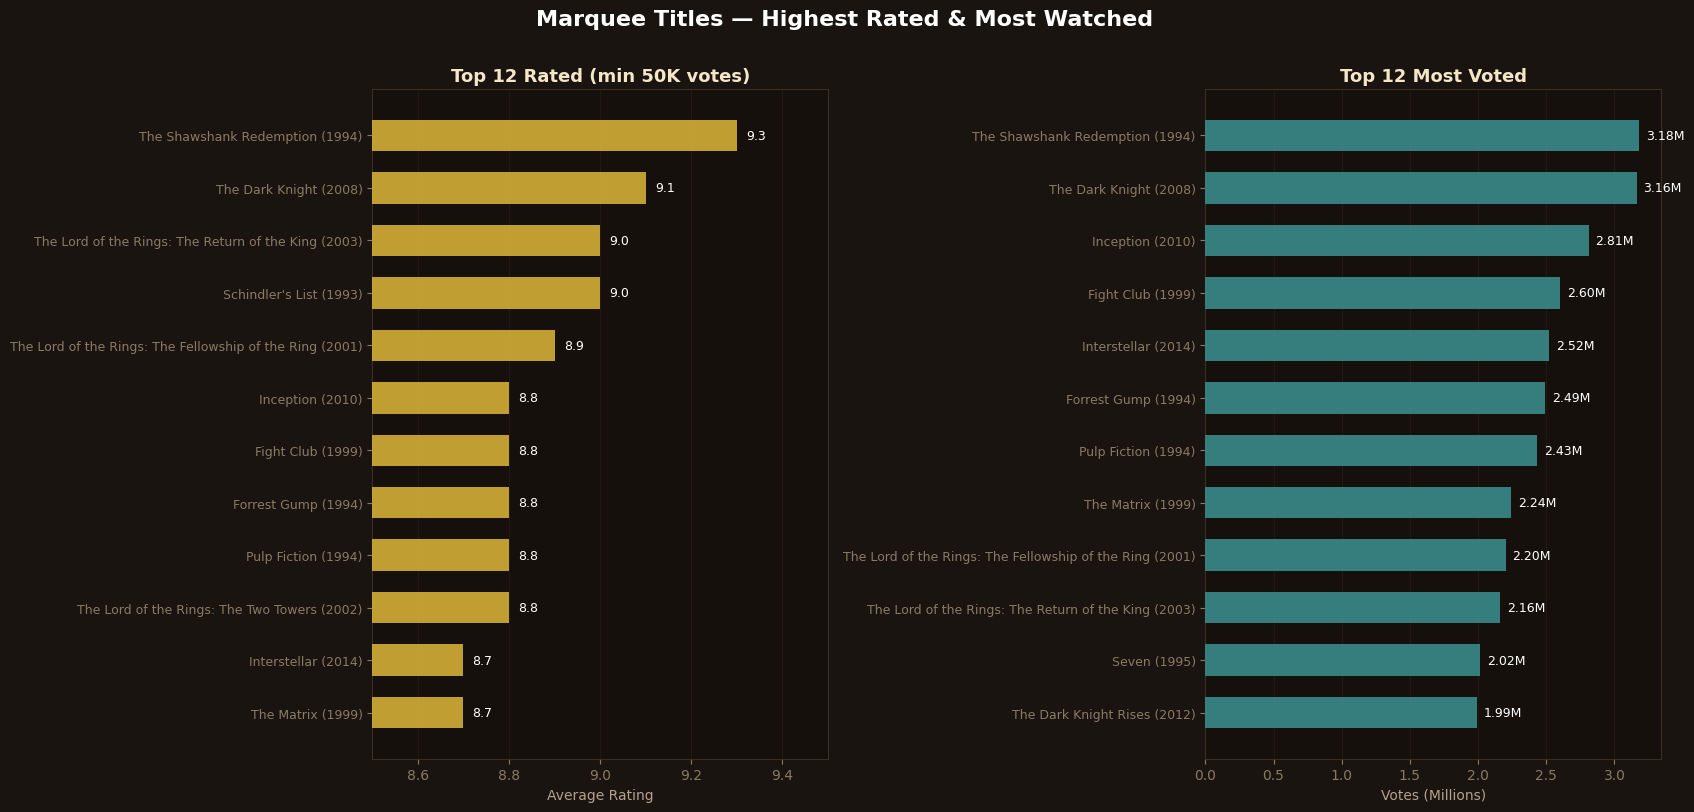

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(17, 8))
fig.patch.set_facecolor(BG)
fig.suptitle('Marquee Titles — Highest Rated & Most Watched', fontsize=16, fontweight='bold', color='white', y=1.01)

# 1. Top 12 rated (min 50K votes to exclude obscure perfect scores)
ax = axes[0]
qualified = df[df['num_votes']>=50000].nlargest(12, 'average_rating')
ax.barh(range(12), qualified['average_rating'].values[::-1], color=GOLD, height=0.6, zorder=3, edgecolor='none', alpha=0.9)
ax.set_yticks(range(12))
ax.set_yticklabels([f"{t} ({y})" for t,y in zip(qualified['title'].values[::-1], qualified['year'].values[::-1])], fontsize=9)
ax.set_xlabel('Average Rating')
ax.set_title('Top 12 Rated (min 50K votes)', fontweight='bold')
for i, v in enumerate(qualified['average_rating'].values[::-1]):
    ax.text(v+0.02, i, f'{v:.1f}', va='center', fontsize=9, color='white')
ax.set_xlim(8.5, 9.5)
ax.grid(axis='x', zorder=0); ax.set_axisbelow(True)

# 2. Most voted (popularity)
ax = axes[1]
most_voted = df.nlargest(12, 'num_votes')
ax.barh(range(12), most_voted['num_votes'].values[::-1]/1e6, color=TEAL, height=0.6, zorder=3, edgecolor='none', alpha=0.9)
ax.set_yticks(range(12))
ax.set_yticklabels([f"{t} ({y})" for t,y in zip(most_voted['title'].values[::-1], most_voted['year'].values[::-1])], fontsize=9)
ax.set_xlabel('Votes (Millions)')
ax.set_title('Top 12 Most Voted', fontweight='bold')
for i, v in enumerate(most_voted['num_votes'].values[::-1]):
    ax.text(v/1e6+0.05, i, f'{v/1e6:.2f}M', va='center', fontsize=9, color='white')
ax.grid(axis='x', zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('06_alltime_greats.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 12. Key Takeaways <a id='12'></a>


<div style="background:#1a1410;border-radius:12px;border:2px solid #d4af37;padding:0;font-family:'Georgia',serif;overflow:hidden;">

  <div style="text-align:center;padding:18px 0;border-bottom:1px solid #3a2f20;">
    <span style="color:#d4af37;font-size:0.7rem;letter-spacing:4px;">★ ★ ★ CLOSING CREDITS ★ ★ ★</span>
  </div>

  <div style="padding:26px 40px;display:grid;grid-template-columns:1fr 1fr;gap:16px;">
    <div style="background:#15100c;border-radius:8px;padding:16px 18px;border-left:3px solid #d4af37;">
      <div style="color:#d4af37;font-size:0.78rem;font-weight:700;margin-bottom:8px;">📉 RATINGS ARE DECLINING — BUT WHY?</div>
      <p style="color:#b5a18a;margin:0;font-size:0.84rem;line-height:1.75;">Mean rating fell from 6.55 in the 1980s to 6.23 in the 2020s. Part of this is likely a maturity effect:
      newer films simply haven't accumulated the years of audience re-watching and critical reassessment that
      lets truly great older films rise to the top of the catalog — median vote counts are far lower for
      recent decades. This is a measurement artefact worth separating from any claim about actual film quality.</p>
    </div>
    <div style="background:#15100c;border-radius:8px;padding:16px 18px;border-left:3px solid #c0392b;">
      <div style="color:#c0392b;font-size:0.78rem;font-weight:700;margin-bottom:8px;">🎭 GENRE QUALITY HIERARCHY</div>
      <p style="color:#b5a18a;margin:0;font-size:0.84rem;line-height:1.75;">Documentaries (7.31) and Animation (7.17) post the highest average ratings; Horror (5.56) sits at the
      bottom by a wide margin. This likely reflects selection bias — only the best documentaries get made
      and widely rated, while horror is produced in much higher volume at lower average budget and ambition.</p>
    </div>
    <div style="background:#15100c;border-radius:8px;padding:16px 18px;border-left:3px solid #3a8a8a;">
      <div style="color:#3a8a8a;font-size:0.78rem;font-weight:700;margin-bottom:8px;">⏱️ LENGTH SIGNALS AMBITION</div>
      <p style="color:#b5a18a;margin:0;font-size:0.84rem;line-height:1.75;">Runtime correlates positively with rating (r=0.312) — films over 150 minutes average 7.04 vs 6.01 for
      80-99 minute films. Longer runtimes typically signal larger budgets, more ambitious storytelling, or
      awards-season prestige projects, all of which independently correlate with quality perception.</p>
    </div>
    <div style="background:#15100c;border-radius:8px;padding:16px 18px;border-left:3px solid #9370a8;">
      <div style="color:#9370a8;font-size:0.78rem;font-weight:700;margin-bottom:8px;">🎟️ POPULARITY AND QUALITY ARE LINKED</div>
      <p style="color:#b5a18a;margin:0;font-size:0.84rem;line-height:1.75;">Films with 500K+ votes average 7.74 vs just 6.20 for films under 1K votes — a steep, consistent gradient.
      This is partly survivorship bias (bad films rarely attract huge audiences) and partly genuine
      consensus-building: widely-watched films have been vetted by far more critical eyes.</p>
    </div>
    <div style="background:#15100c;border-radius:8px;padding:16px 18px;border-left:3px solid #5a8a5a;grid-column:1/-1;">
      <div style="color:#5a8a5a;font-size:0.78rem;font-weight:700;margin-bottom:8px;">🤖 PREDICTING ACCLAIM FROM METADATA ALONE</div>
      <p style="color:#b5a18a;margin:0;font-size:0.84rem;line-height:1.75;">Using only year, runtime, genre count, and primary genre — deliberately excluding vote count or any
      rating-derived signal to avoid leakage — the classifier's ROC-AUC (reported above) shows how much
      "acclaim" can be anticipated from a film's basic shape alone, before a single audience member has voted.</p>
    </div>

  </div>

  <div style="background:#15100c;padding:12px 40px;border-top:1px solid #3a2f20;">
    <p style="margin:0;color:#5a4d3c;font-size:0.74rem;line-height:1.6;">
      <strong style='color:#8a7a63;'>Production notes:</strong> This is IMDb user-rating data, not critical consensus — popularity, marketing
      reach, and audience demographics on IMDb all shape these numbers. The 2026 entries are necessarily
      incomplete (only 62 titles, partial year). Vote count and rating are entangled in ways that make causal
      claims about "what makes a movie good" difficult to support from this data alone.
    </p>
  </div>

  <div style="text-align:center;padding:10px 0;background:#0f0b08;">
    <span style="font-size:0.7rem;color:#3a2f20;">FIN · Muhammad Aamir · 16,252 Titles · Kaggle Notebook</span>
  </div>
</div>
